# Clustering Optimization (Solution)

<a href="https://colab.research.google.com/github/HassanAlgoz/dl/blob/main/modules/M0/01-clustering/clustering_optimization_solution.ipynb" target="_blank">
  <img src="https://raw.githubusercontent.com/HassanAlgoz/dl/main/assets/Open%20in%20Colab-F9AB00.svg" alt="Open in Colab" height="50"/>
</a>


In [ ]:
# --- Setup: Clone repo & cd into correct folder (for lab setup convenience) ---
import os
import subprocess

repo_url = "https://github.com/HassanAlgoz/dl.git"
lab_folder = "dl/modules/M0/01-clustering"

# Only clone if the folder doesn't exist
if not os.path.exists(lab_folder):
    subprocess.run(["git", "clone", repo_url])

# Change working directory to the lab folder
os.chdir(lab_folder)


## Context

[**Old Faithful** Dataset](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/faithful.html): Waiting times between eruptions and the duration of each eruption for the Old Faithful geyser in Yellowstone National Park, Wyoming, USA. The version used here contains 272 observations with two real-valued attributes.

- Old Faithful is a cone geyser in Yellowstone's Upper Geyser Basin and one of the park's most predictable thermal features, erupting at fairly regular intervals.

- Each row records one complete eruption: how long it lasted (`duration`, in minutes) and how long until the next one (`waiting`, in minutes).

- The data show two distinct eruption regimes — shorter eruptions tend to be followed by shorter waits, while longer eruptions tend to be followed by longer waits — which makes this a classic dataset for visualizing and validating clustering methods.

- This version matches the one bundled with R's `faithful` dataset (column `eruptions` renamed to `duration`), widely used in statistics and machine learning courses.

> Source: Azzalini, A. and Bowman, A. W. (1990). *A look at some data on the Old Faithful geyser.* Applied Statistics, 39, 357–365.

# Imports

In [1]:
# %pip install -qqq numpy pandas scikit-learn matplotlib seaborn


In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

matplotlib.style.use('ggplot')


# Load Data

Load the data and take a first look. Do you think this data could benefit from clustering?

In [3]:
df = pd.read_csv("../data/geyser.csv")
df.head()


,duration,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


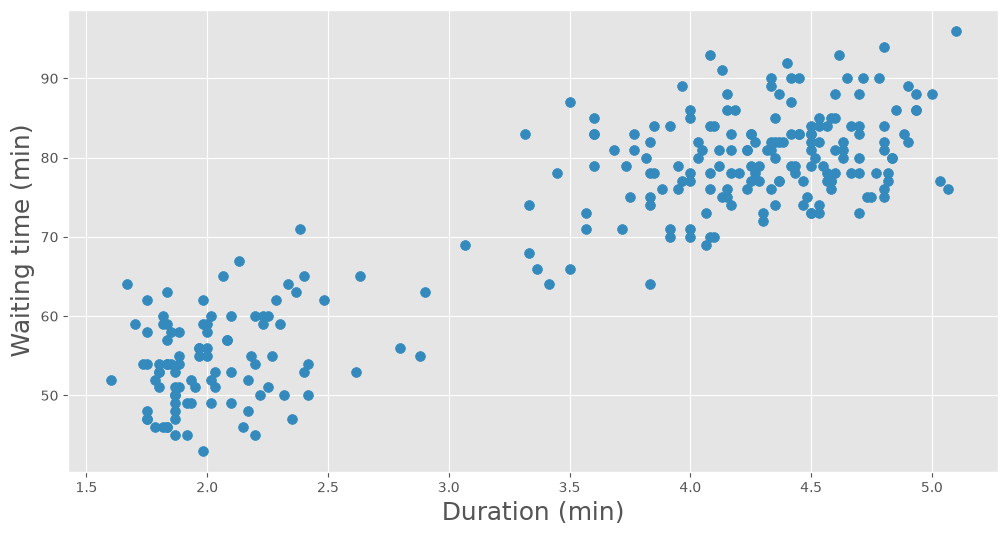

In [4]:
df.plot(kind="scatter", x="duration", y="waiting", figsize=(12, 6), s=50)
plt.xlabel("Duration (min)", fontsize=18)
plt.ylabel("Waiting time (min)", fontsize=18);


In [5]:
X = df[["duration", "waiting"]]


In [6]:
# There's a VERY important step before fitting our K-Means Model. Any ideas?
sc = StandardScaler()
X_scaled = sc.fit_transform(X)


In [7]:
# Fit a K-means clustering model
km = KMeans(n_clusters=2, random_state=42)
km.fit(X_scaled)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 2)","[

## What did we discover?

### I. Cluster Predictions

In [8]:
# Option 1: Class attribute

km.labels_


array([0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0], dtype=int32)

In [9]:
# Option 2: Predict

km.predict(X_scaled)


array([0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0], dtype=int32)

In [10]:
# Attach predicted cluster to original points

df['cluster'] = km.labels_
df.head()


,duration,waiting,cluster
0,3.600,79,0
1,1.800,54,1
2,3.333,74,0
3,2.283,62,1
4,4.533,85,0


### II. Centroids

In [11]:
# Option 1: Using groupby

df.groupby('cluster').mean()


,duration,waiting
cluster,,
0,4.296328,80.080460
1,2.052204,54.591837


In [12]:
# Option 2: (Preferred method) Using cluster_centers_

km.cluster_centers_

# But wait... why does this not match the one above?!


array([[ 0.70970327,  0.67674488],
       [-1.26008539, -1.20156744]])

In [13]:
# Remember, we scaled this! We need to "unscale".

centroids = sc.inverse_transform(km.cluster_centers_)


## Visually Verifying Cluster Labels

In [14]:
centroids = pd.DataFrame(
    centroids,
    columns=["duration", "waiting"]
)
centroids


,duration,waiting
0,4.296328,80.080460
1,2.052204,54.591837


<Figure size 1000x800 with 0 Axes>

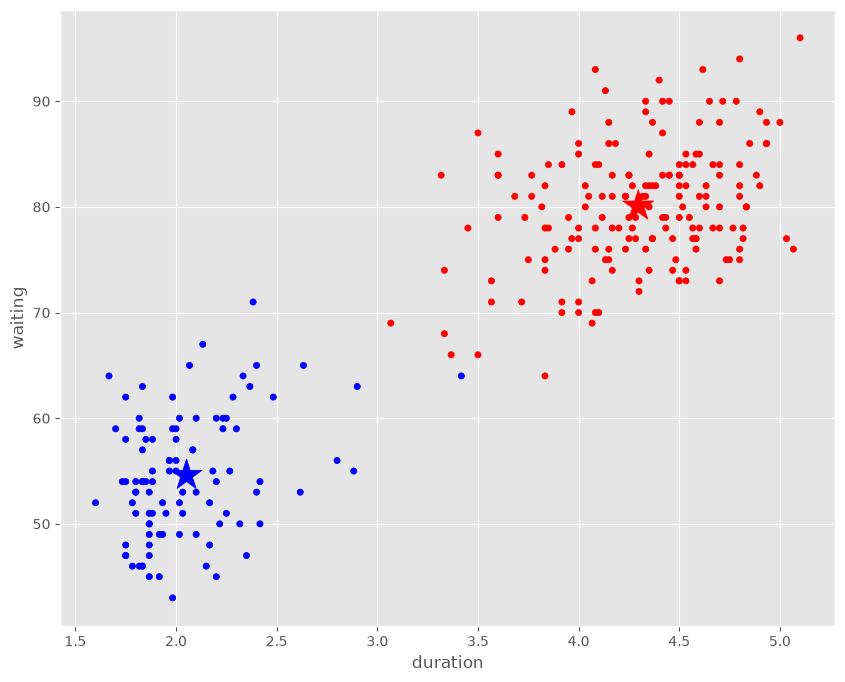

In [15]:
plt.figure(figsize=(10, 8))

colors = ["red", "blue"]
df["color"] = df["cluster"].map(lambda p: colors[p])

ax = df.plot(
    kind="scatter",
    x="duration", y="waiting",
    figsize=(10, 8),
    c=df["color"]
)

centroids.plot(
    kind="scatter",
    x="duration", y="waiting",
    marker="*", c=["r", "b"], s=550, ax=ax
);


# Metrics for Assessing Clusters
---
## Inertia

Sum of squared differences between each point in a cluster and that cluster's centroid.

How dense is each cluster? 


- low inertia = dense cluster
- ranges from 0 to very high values


$$ \sum_{j=0}^{n} (x_j - \mu_i)^2 $$

where $\mu_i$ is a cluster centroid



`.inertia_` is an attribute of a fitted sklearn's kmeans object

#### Lower inertia is better! Though be cautious with adding too many clusters.

#### Get the inertia

In [16]:
km.inertia_


79.57595948827702

---
## Silhouette Score

Tells you how much closer data points are to their own clusters than to the nearest neighbor cluster.

How far apart are the clusters?
- ranges from -1 to 1
- high silhouette score means the clusters are well separated



### $s_i = \frac{b_i - a_i}{max\{a_i, b_i\}}$

Where:
- $a_i$ = Cohesion: Mean distance of points within a cluster from each other.
- $b_i$ = Separation: Mean distance from point $x_i$ to all points in the next nearest cluster.

Use scikit-learn: `metrics.silhouette_score(X_scaled, labels)`.

#### Higher silhouette score is better!


#### Compute the silhouette score 

In [17]:
from sklearn.metrics import silhouette_score


In [18]:
silhouette_score(X_scaled, km.labels_)


0.7451774401188772

# Using the elbow method to choose _k_
---

The [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) is one possible method to help narrow in on the ideal value of **K**. 

### Choose the number of clusters where the next cluster doesn't significantly improve performance. 

#### Let's use the `.inertia_` method as our evaluation metric

In [19]:
inertia_list = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)
    
inertia_list


[544.0,
 79.57595948827702,
 56.828687546339054,
 46.72262081019579,
 34.27996235947026,
 27.284261501679804,
 24.291873151848726,
 21.065831792834963,
 18.907202646766095,
 17.671040748521133]

#### Analyze the above

- Do you see the **"elbow"**?

- What's the best value for _k_?




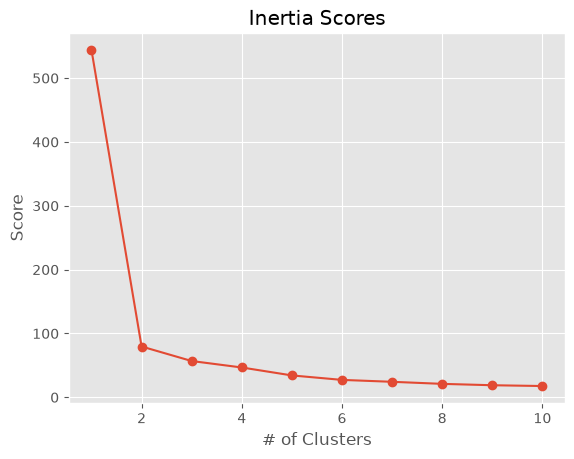

In [20]:
plt.plot(range(1, 11), inertia_list, marker='o')
plt.xlabel('# of Clusters')
plt.ylabel('Score')
plt.title('Inertia Scores');


#### Now let's make a plot with the silhouette score

## Remember: Higher is Better for Silhouette Score!

In [21]:
silhouette_list = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    silhouette_list.append(silhouette_score(X_scaled, kmeans.labels_))
silhouette_list


[0.7451774401188772,
 0.48627680705614984,
 0.45709063161843455,
 0.36281363365005226,
 0.39195723855368747,
 0.36011380913058155,
 0.36160386732232574,
 0.35813454469200584,
 0.35638322508183007]

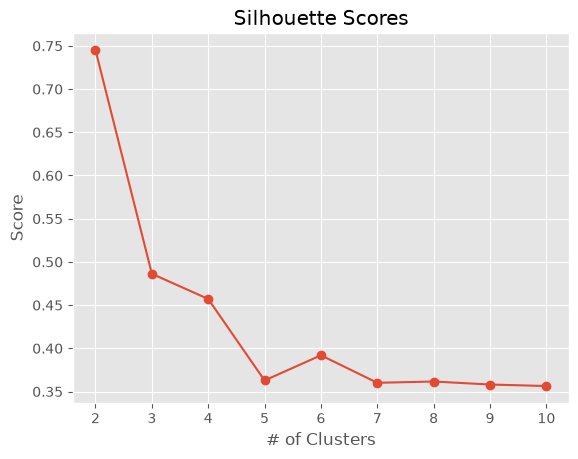

In [22]:
plt.plot(range(2, 11), silhouette_list, marker='o')
plt.xlabel('# of Clusters')
plt.ylabel('Score')
plt.title('Silhouette Scores');


#### What _k_ should we choose?

2! despite the elboew, because the clusters are possible to discern visually; which is a higher priority insight than the elbow method.